In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [19]:
def load_cifar10_dataset():
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
    ])
    
    train_dataset = torchvision.datasets.CIFAR10(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )
    
    test_dataset = torchvision.datasets.CIFAR10(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )
    
    return train_dataset, test_dataset

In [20]:
def explore_dataset(dataset):

    print("Dataset size:", len(dataset))

    image, label = dataset[0]

    print("Image shape:", image.shape)
    print("Label:", label)

In [21]:
def visualize_samples(dataset, num_images=6):

    classes = dataset.classes

    fig, axes = plt.subplots(1, num_images, figsize=(12,4))

    for i in range(num_images):

        image, label = dataset[i]

        axes[i].imshow(image.permute(1,2,0))
        axes[i].set_title(classes[label])
        axes[i].axis("off")

    plt.show()

In [22]:
def pixel_statistics(dataset, sample_size=1000):

    pixels = []

    for i in range(sample_size):

        img, _ = dataset[i]
        pixels.append(img.numpy().flatten())

    pixels = np.concatenate(pixels)

    print("Min pixel:", np.min(pixels))
    print("Max pixel:", np.max(pixels))
    print("Mean pixel:", np.mean(pixels))

In [23]:
def create_dataloaders(train_dataset, test_dataset, batch_size=64):

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, test_loader

In [24]:
class SparseAutoencoder(nn.Module):

    def __init__(self, input_dim=3072, hidden_dim=1024):

        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid()
        )

        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Tanh()
        )

    def forward(self, x):

        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return encoded, decoded

In [25]:
def sparsity_penalty(encoded, rho=0.05, sparsity_lambda=1e-4):

    rho_hat = torch.mean(encoded, dim=0)

    rho = torch.tensor(rho).to(encoded.device)

    epsilon = 1e-8
    rho_hat = torch.clamp(rho_hat, epsilon, 1-epsilon)

    kl = rho * torch.log(rho/rho_hat) + \
         (1-rho) * torch.log((1-rho)/(1-rho_hat))

    return sparsity_lambda * torch.sum(kl)

In [26]:
def initialize_model(hidden_dim=1024, lr=0.0001):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = SparseAutoencoder(hidden_dim=hidden_dim).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    criterion = nn.MSELoss()

    return model, optimizer, criterion, device

In [27]:
def train_model(model, train_loader, optimizer, criterion, device,
                epochs=20, sparsity_lambda=1e-4):

    model.train()

    for epoch in range(epochs):

        total_loss = 0

        for images, _ in train_loader:

            images = images.view(images.size(0), -1).to(device)

            optimizer.zero_grad()

            encoded, decoded = model(images)

            recon_loss = criterion(decoded, images)

            sparse_loss = sparsity_penalty(encoded, sparsity_lambda=sparsity_lambda)

            loss = recon_loss + sparse_loss

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

In [28]:
def evaluate_model(model, test_loader, criterion, device):

    model.eval()

    test_loss = 0

    with torch.no_grad():

        for images, _ in test_loader:

            images = images.view(images.size(0), -1).to(device)

            _, outputs = model(images)

            loss = criterion(outputs, images)

            test_loss += loss.item()

    final_loss = test_loss/len(test_loader)

    print("Test Reconstruction Loss:", final_loss)

    return final_loss

In [29]:
def visualize_reconstruction(model, test_loader, device, num_images=8):

    model.eval()

    images, _ = next(iter(test_loader))

    images = images[:num_images].to(device)

    flat = images.view(images.size(0), -1)

    with torch.no_grad():
        _, outputs = model(flat)

    outputs = outputs.view(-1,3,32,32).cpu()
    images = images.cpu()

    fig, axes = plt.subplots(2, num_images, figsize=(12,4))

    for i in range(num_images):

        axes[0,i].imshow(images[i].permute(1,2,0))
        axes[0,i].axis("off")

        axes[1,i].imshow(outputs[i].permute(1,2,0))
        axes[1,i].axis("off")

    axes[0,0].set_title("Original")
    axes[1,0].set_title("Reconstructed")

    plt.show()

In [30]:
def run_sparsity_experiment(sparsity_values):

    train_dataset, test_dataset = load_cifar10_dataset()

    train_loader, test_loader = create_dataloaders(train_dataset, test_dataset)

    results = {}

    for s in sparsity_values:

        print("Training with sparsity lambda =", s)

        model, optimizer, criterion, device = initialize_model()

        train_model(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            sparsity_lambda=s
        )

        loss = evaluate_model(model, test_loader, criterion, device)

        visualize_reconstruction(model, test_loader, device)

        results[s] = loss

    return results

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Dataset size: 50000
Image shape: torch.Size([3, 32, 32])
Label: 6


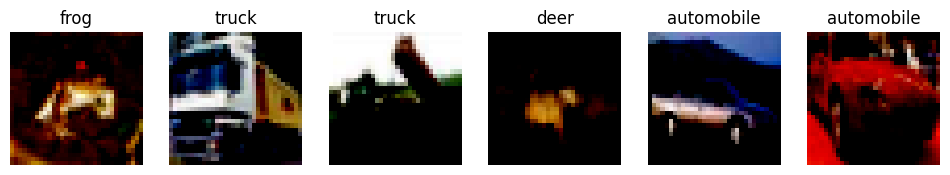

Min pixel: -1.0
Max pixel: 1.0
Mean pixel: -0.054194443
Training with sparsity lambda = 1e-05
Epoch 1/20 | Loss: 0.0822
Epoch 2/20 | Loss: 0.0416
Epoch 3/20 | Loss: 0.0318
Epoch 4/20 | Loss: 0.0267
Epoch 5/20 | Loss: 0.0235
Epoch 6/20 | Loss: 0.0212
Epoch 7/20 | Loss: 0.0196
Epoch 8/20 | Loss: 0.0183
Epoch 9/20 | Loss: 0.0173
Epoch 10/20 | Loss: 0.0164
Epoch 11/20 | Loss: 0.0157
Epoch 12/20 | Loss: 0.0151
Epoch 13/20 | Loss: 0.0145
Epoch 14/20 | Loss: 0.0141
Epoch 15/20 | Loss: 0.0136
Epoch 16/20 | Loss: 0.0133
Epoch 17/20 | Loss: 0.0129
Epoch 18/20 | Loss: 0.0126
Epoch 19/20 | Loss: 0.0124
Epoch 20/20 | Loss: 0.0121
Test Reconstruction Loss: 0.009046526053315325


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

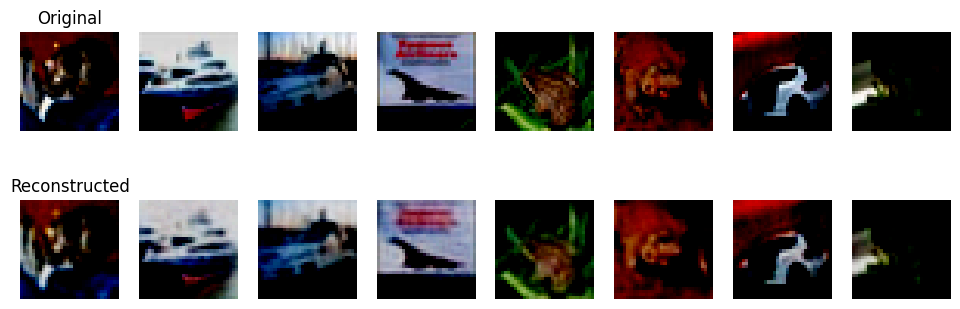

Training with sparsity lambda = 5e-05
Epoch 1/20 | Loss: 0.0983
Epoch 2/20 | Loss: 0.0560
Epoch 3/20 | Loss: 0.0456
Epoch 4/20 | Loss: 0.0399
Epoch 5/20 | Loss: 0.0361
Epoch 6/20 | Loss: 0.0333
Epoch 7/20 | Loss: 0.0311
Epoch 8/20 | Loss: 0.0293
Epoch 9/20 | Loss: 0.0278
Epoch 10/20 | Loss: 0.0265
Epoch 11/20 | Loss: 0.0253
Epoch 12/20 | Loss: 0.0243
Epoch 13/20 | Loss: 0.0233
Epoch 14/20 | Loss: 0.0225
Epoch 15/20 | Loss: 0.0217
Epoch 16/20 | Loss: 0.0210
Epoch 17/20 | Loss: 0.0203
Epoch 18/20 | Loss: 0.0197
Epoch 19/20 | Loss: 0.0191
Epoch 20/20 | Loss: 0.0185
Test Reconstruction Loss: 0.010514946755282818


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

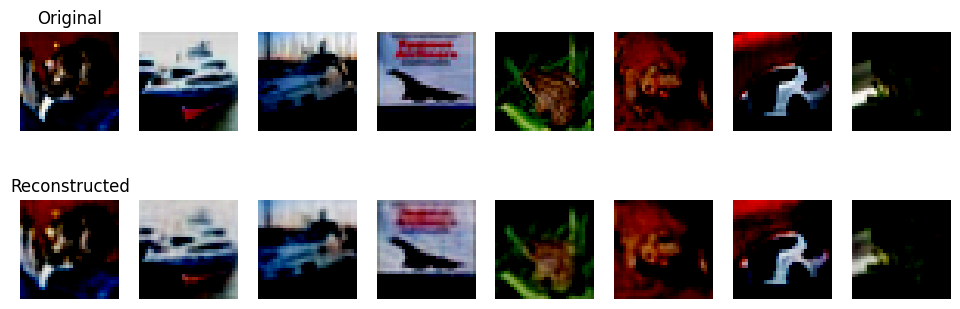

Training with sparsity lambda = 0.0001
Epoch 1/20 | Loss: 0.1164
Epoch 2/20 | Loss: 0.0717
Epoch 3/20 | Loss: 0.0602
Epoch 4/20 | Loss: 0.0534
Epoch 5/20 | Loss: 0.0485
Epoch 6/20 | Loss: 0.0448
Epoch 7/20 | Loss: 0.0418
Epoch 8/20 | Loss: 0.0393
Epoch 9/20 | Loss: 0.0371
Epoch 10/20 | Loss: 0.0352
Epoch 11/20 | Loss: 0.0334
Epoch 12/20 | Loss: 0.0319
Epoch 13/20 | Loss: 0.0305
Epoch 14/20 | Loss: 0.0292
Epoch 15/20 | Loss: 0.0279
Epoch 16/20 | Loss: 0.0268
Epoch 17/20 | Loss: 0.0258
Epoch 18/20 | Loss: 0.0248
Epoch 19/20 | Loss: 0.0238
Epoch 20/20 | Loss: 0.0230
Test Reconstruction Loss: 0.012381688145932499


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

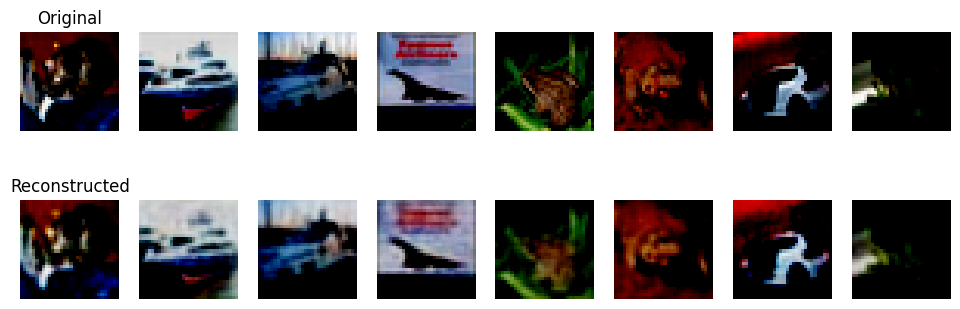

Training with sparsity lambda = 0.0005
Epoch 1/20 | Loss: 0.2219
Epoch 2/20 | Loss: 0.1497
Epoch 3/20 | Loss: 0.1282
Epoch 4/20 | Loss: 0.1153
Epoch 5/20 | Loss: 0.1061
Epoch 6/20 | Loss: 0.0988
Epoch 7/20 | Loss: 0.0927
Epoch 8/20 | Loss: 0.0873
Epoch 9/20 | Loss: 0.0826
Epoch 10/20 | Loss: 0.0784
Epoch 11/20 | Loss: 0.0743
Epoch 12/20 | Loss: 0.0707
Epoch 13/20 | Loss: 0.0672
Epoch 14/20 | Loss: 0.0638
Epoch 15/20 | Loss: 0.0607
Epoch 16/20 | Loss: 0.0576
Epoch 17/20 | Loss: 0.0548
Epoch 18/20 | Loss: 0.0520
Epoch 19/20 | Loss: 0.0494
Epoch 20/20 | Loss: 0.0469
Test Reconstruction Loss: 0.023434802344080748


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

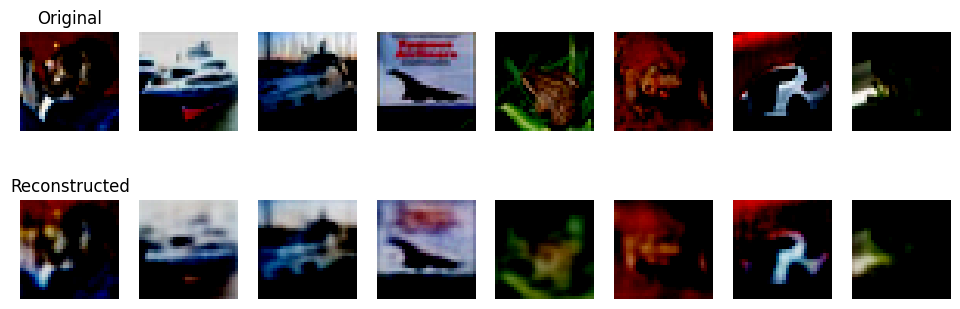

Training with sparsity lambda = 0.001
Epoch 1/20 | Loss: 0.3295
Epoch 2/20 | Loss: 0.2234
Epoch 3/20 | Loss: 0.1921
Epoch 4/20 | Loss: 0.1734
Epoch 5/20 | Loss: 0.1602
Epoch 6/20 | Loss: 0.1497
Epoch 7/20 | Loss: 0.1411
Epoch 8/20 | Loss: 0.1331
Epoch 9/20 | Loss: 0.1264
Epoch 10/20 | Loss: 0.1197
Epoch 11/20 | Loss: 0.1135
Epoch 12/20 | Loss: 0.1079
Epoch 13/20 | Loss: 0.1024
Epoch 14/20 | Loss: 0.0972
Epoch 15/20 | Loss: 0.0918
Epoch 16/20 | Loss: 0.0868
Epoch 17/20 | Loss: 0.0819
Epoch 18/20 | Loss: 0.0773
Epoch 19/20 | Loss: 0.0728
Epoch 20/20 | Loss: 0.0685
Test Reconstruction Loss: 0.03122459906064401


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

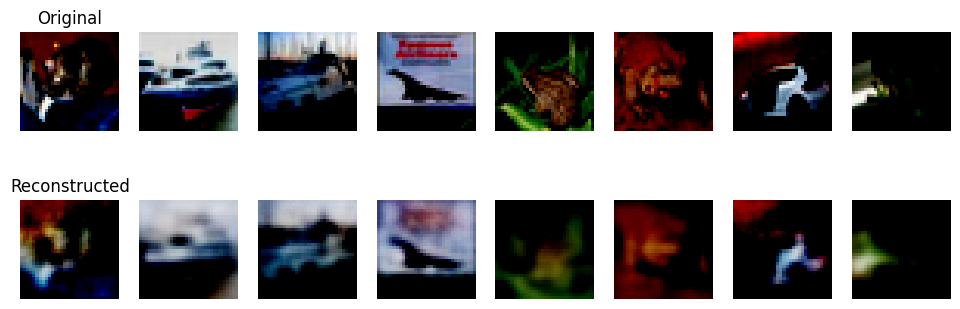

{1e-05: 0.009046526053315325, 5e-05: 0.010514946755282818, 0.0001: 0.012381688145932499, 0.0005: 0.023434802344080748, 0.001: 0.03122459906064401}


In [32]:
train_dataset, test_dataset = load_cifar10_dataset()

explore_dataset(train_dataset)

visualize_samples(train_dataset)

pixel_statistics(train_dataset)

results = run_sparsity_experiment([
    1e-5,
    5e-5,
    1e-4,
    5e-4,
    1e-3
])

print(results)

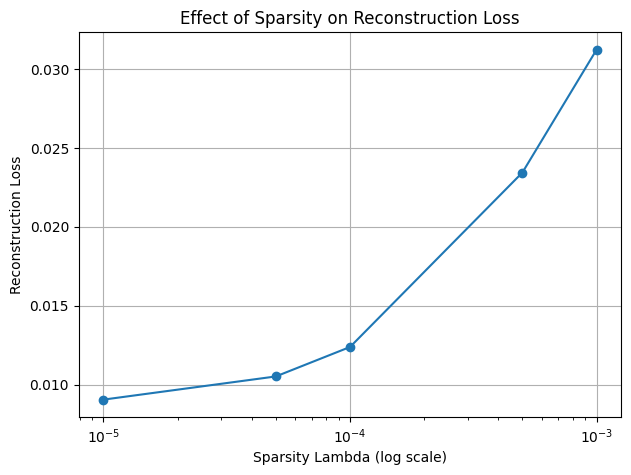

In [33]:
def plot_sparsity_results(results):

    sparsity_values = list(results.keys())
    losses = list(results.values())

    plt.figure(figsize=(7,5))

    plt.plot(sparsity_values, losses, marker='o')

    plt.xscale("log")

    plt.xlabel("Sparsity Lambda (log scale)")
    plt.ylabel("Reconstruction Loss")
    plt.title("Effect of Sparsity on Reconstruction Loss")

    plt.grid(True)

    plt.show()

plot_sparsity_results(results)